## EDA

In [166]:
# =========================
# [1] IMPORT + SETTINGS + PATH
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FIBS_PATH  = "/Users/filipposaccomano/Downloads/Metabolomics data Mario Negri/FIBS_Single molecule_Feb26.xlsx"
MICRO_PATH = "/Users/filipposaccomano/Downloads/Metabolomics data Mario Negri/Microbiota_Single molecule_Feb26.xlsx"
SHEET_NAME = 0

TIMES = [1, 2, 3, 4]
MAX_PCT_FLOOR = 20.0

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

In [167]:
# =========================
# [2] LOAD FIBS: usa riga "Feature ID" come codici colonne metaboliti
# =========================
raw_f = pd.read_excel(FIBS_PATH, sheet_name=SHEET_NAME, header=None)

code_row = raw_f.iloc[0]                 # Feature ID (codici)
name_row = raw_f.iloc[1].astype(str)     # header (Code, Time, FI, ... + nomi metaboliti)
data_f   = raw_f.iloc[2:].copy()
data_f.columns = name_row

meta_cols_master = [
    "HMDB_Metabolite","Code","Time","FI","Sesso","BMI1",
    "C_renale","C_epatic10","AnniScuo","Subject"
]
meta_cols_fibs = [c for c in meta_cols_master if c in data_f.columns]

# rename: nome metabolita -> codice (stringa)
rename_fibs = {}
for j, col in enumerate(data_f.columns):
    if col in meta_cols_fibs:
        continue
    c = code_row.iloc[j]
    if pd.isna(c):
        continue
    try:
        f = float(c)
        c_str = str(int(f)) if f.is_integer() else str(f)
    except:
        c_str = str(c).strip()
    rename_fibs[col] = c_str

df_fibs = data_f.rename(columns=rename_fibs).copy()

# typing
for c in ["Code","Time","FI"]:
    if c in df_fibs.columns:
        df_fibs[c] = pd.to_numeric(df_fibs[c], errors="coerce")

df_fibs = df_fibs.dropna(subset=["Code","Time"]).copy()
df_fibs["Code"] = df_fibs["Code"].astype(int)
df_fibs["Time"] = df_fibs["Time"].astype(int)
df_fibs = df_fibs[df_fibs["Time"].isin(TIMES)].copy()

fibs_met_cols = [c for c in df_fibs.columns if c not in meta_cols_fibs]

print("FIBS shape:", df_fibs.shape)
print("FIBS metaboliti:", len(fibs_met_cols))

FIBS shape: (3342, 97)
FIBS metaboliti: 88


In [168]:
# =========================
# [3] LOAD MICROBIOTA: normalizza colonne + codici metaboliti come stringhe
# =========================
micro = pd.read_excel(MICRO_PATH, sheet_name=0, header=0)
micro.columns = [str(c).strip() for c in micro.columns]

# normalizza id/time
micro = micro.rename(columns={"TIME":"Time","time":"Time","ID Code":"Code","CODE":"Code","code":"Code"})

# se esistono colonne tipo Subject/ID inutili, le togliamo
micro = micro.drop(columns=[c for c in ["ID"] if c in micro.columns], errors="ignore").copy()

micro["Code"] = pd.to_numeric(micro["Code"], errors="coerce")
micro["Time"] = pd.to_numeric(micro["Time"], errors="coerce")
micro = micro.dropna(subset=["Code","Time"]).copy()

micro["Code"] = micro["Code"].astype(int)
micro["Time"] = micro["Time"].astype(int)
micro = micro[micro["Time"].isin(TIMES)].copy()

# normalizza nomi colonne metaboliti (es. 130604.0 -> "130604")
micro_met_cols = [c for c in micro.columns if c not in ["Code","Time", "Subject"]]

def norm_code(x):
    try:
        f = float(x)
        return str(int(f)) if f.is_integer() else str(f)
    except:
        return str(x).strip()

micro = micro.rename(columns={c: norm_code(c) for c in micro_met_cols})
micro_met_cols = [c for c in micro.columns if c not in ["Code","Time", "Subject"]]

# forza numerico nei metaboliti
micro[micro_met_cols] = micro[micro_met_cols].apply(pd.to_numeric, errors="coerce")

print("MICRO shape:", micro.shape)
print("MICRO metaboliti:", len(micro_met_cols))

MICRO shape: (3403, 110)
MICRO metaboliti: 107


In [169]:
# =========================
# [4] RIMUOVI DUPLICATI metaboliti: se codice esiste già in FIBS, lo tolgo da Microbiota
# =========================
dup_codes = sorted(list(set(micro_met_cols).intersection(set(fibs_met_cols))))
if dup_codes:
    print("Duplicati (stesso codice in FIBS e Microbiota) -> tolti da Microbiota:", dup_codes)
    micro = micro.drop(columns=dup_codes).copy()

micro_met_cols = [c for c in micro.columns if c not in ["Code","Time", "Subject"]]
print("MICRO metaboliti dopo dedup:", len(micro_met_cols))

Duplicati (stesso codice in FIBS e Microbiota) -> tolti da Microbiota: ['130604', '135585']
MICRO metaboliti dopo dedup: 105


In [170]:
# =========================
# [5] CONTROLLI PAZIENTI: tieni solo chi ha T1..T4 completi in ENTRAMBI (=> 609)
# =========================
def complete_codes(df_):
    n = df_.groupby("Code")["Time"].nunique()
    return set(n[n == len(TIMES)].index.astype(int))

cc_fibs  = complete_codes(df_fibs[["Code","Time"]])
cc_micro = complete_codes(micro[["Code","Time"]])
common   = sorted(list(cc_fibs & cc_micro))

print("Pazienti completi (T1..T4) FIBS:", len(cc_fibs))
print("Pazienti completi (T1..T4) MICRO:", len(cc_micro))
print("Intersezione (useremo questi):", len(common))

only_fibs = sorted(list(cc_fibs - cc_micro))
if only_fibs:
    print("Pazienti completi solo in FIBS (esclusi):", only_fibs)

df_fibs_c = df_fibs[df_fibs["Code"].isin(common)].copy()
micro_c   = micro[micro["Code"].isin(common)].copy()

# merge finale su Code-Time
df = df_fibs_c.merge(micro_c, on=["Code","Time"], how="inner")

print("\nDF finale (FIBS + Microbiota):", df.shape)
print("Pazienti:", df["Code"].nunique(), "| righe attese:", df["Code"].nunique()*4, "| righe reali:", len(df))
print("Time presenti:", sorted(df["Time"].unique()))

Pazienti completi (T1..T4) FIBS: 610
Pazienti completi (T1..T4) MICRO: 609
Intersezione (useremo questi): 609
Pazienti completi solo in FIBS (esclusi): [34]

DF finale (FIBS + Microbiota): (2436, 203)
Pazienti: 609 | righe attese: 2436 | righe reali: 2436
Time presenti: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [171]:
# =========================
# [6] CHECK HARD: ogni paziente deve avere esattamente [1,2,3,4]
# =========================
chk = df.groupby("Code")["Time"].apply(lambda s: sorted(s.unique()))
bad = chk[chk.apply(lambda t: t != TIMES)]

print("Pazienti con timepoint non perfetti:", bad.shape[0])
if bad.shape[0] > 0:
    display(bad.head(20))

Pazienti con timepoint non perfetti: 0


In [172]:
# =========================
# [7] DEFINISCI META VS METABOLITI (evita errori tipo 'Subject')
# =========================
meta_cols = [c for c in meta_cols_master if c in df.columns]
keep_meta = ["Code","Time"]
if "FI" in df.columns: 
    keep_meta.append("FI")

# aggiungi gli altri meta se presenti
for c in meta_cols:
    if c not in keep_meta:
        keep_meta.append(c)

met_cols_all = [c for c in df.columns if c not in keep_meta]

# forza numerico solo metaboliti
df[met_cols_all] = df[met_cols_all].apply(pd.to_numeric, errors="coerce")

print("Meta columns:", keep_meta)
print("Metaboliti totali:", len(met_cols_all))
print("Esempio metaboliti:", met_cols_all[:10])

Meta columns: ['Code', 'Time', 'FI', 'HMDB_Metabolite', 'Sesso', 'BMI1', 'C_renale', 'C_epatic10', 'AnniScuo', 'Subject']
Metaboliti totali: 193
Esempio metaboliti: ['133698', '139718', '126659', '106466', '135033', '126346', '103964', '113020', '82833', '99087']


In [173]:
# =========================
# [8] FILTER 1: TOGLI metaboliti con anche 1 solo NaN (stampa lista)
# =========================
nan_any = df[met_cols_all].isna().any(axis=0)

mets_with_nan = nan_any[nan_any].index.tolist()
mets_no_nan   = nan_any[~nan_any].index.tolist()

print("Metaboliti con >=1 NaN (da togliere):", len(mets_with_nan))
if len(mets_with_nan) > 0:
    print(mets_with_nan[:80], "..." if len(mets_with_nan) > 80 else "")

df_nn = df[keep_meta + mets_no_nan].copy()
met_cols_nn = mets_no_nan

print("Metaboliti rimasti senza NaN:", len(met_cols_nn))
print("df_nn shape:", df_nn.shape)

Metaboliti con >=1 NaN (da togliere): 0
Metaboliti rimasti senza NaN: 193
df_nn shape: (2436, 203)


In [174]:
# =========================
# [9] FILTER 2: floor = MIN del metabolita, togli %floor > 50
# =========================
# floor per colonna = minimo valore (ignora NaN, ma qui non ce ne sono)
floors = df_nn[met_cols_nn].min(axis=0)

# % valori uguali al floor
is_floor = df_nn[met_cols_nn].eq(floors, axis=1)
pct_floor = is_floor.mean(axis=0) * 100

mets_high_floor = pct_floor[pct_floor > MAX_PCT_FLOOR].index.tolist()
mets_ok_floor   = pct_floor[pct_floor <= MAX_PCT_FLOOR].index.tolist()

print("Metaboliti con %floor > 50 (da togliere):", len(mets_high_floor))
if len(mets_high_floor) > 0:
    print(mets_high_floor[:80], "..." if len(mets_high_floor) > 80 else "")

df_eda = df_nn[keep_meta + mets_ok_floor].copy()
met_cols_eda = mets_ok_floor

print("\nDF EDA finale:", df_eda.shape)
print("Metaboliti finali:", len(met_cols_eda))

Metaboliti con %floor > 50 (da togliere): 177
['133698', '139718', '126659', '106466', '135033', '126346', '103964', '113020', '82833', '99087', '119236', '168490', '138907', '121811', '120572', '117118', '117123', '127908', '115216', '77320', '140845', '108360', '126673', '95952', '132791', '131236', '110861', '168439', '119396', '107734', '114147', '126338', '130604', '148452', '115483', '133194', '97085', '132942', '139970', '112827', '148969', '135585', '139688', '102818', '95488', '126961', '125270', '119670', '138928', '145525', '143390', '102381', '146389', '139429', '69769', '70501', '88906', '99957', '100525', '105612', '107230', '107747', '115097', '125698', '128641', '132923', '141889', '142686', '154201', '154261', '154918', '154982', '155702', '156439', '173108', '182877', '192291', '199458', '207856', '13944'] ...

DF EDA finale: (2436, 26)
Metaboliti finali: 16


In [175]:
# =========================
# [9B] RINOMINA SOLO I METABOLITI FIBS: feature_id -> nome
# da fare DOPO i controlli EDA
# =========================

# ricostruisco la mappa feature_id -> nome da FIBS
raw_f = pd.read_excel(FIBS_PATH, sheet_name=SHEET_NAME, header=None)

feature_row = raw_f.iloc[0]              # feature IDs
name_row    = raw_f.iloc[1].astype(str)  # nomi metaboliti / header

meta_cols_master = [
    "HMDB_Metabolite","Code","Time","FI","Sesso","BMI1",
    "C_renale","C_epatic10","AnniScuo","Subject"
]

fibs_code_to_name = {}

for j in range(len(name_row)):
    nm = str(name_row.iloc[j]).strip()
    if nm in meta_cols_master:
        continue

    fid = feature_row.iloc[j]
    if pd.isna(fid):
        continue

    try:
        f = float(fid)
        fid_str = str(int(f)) if f.is_integer() else str(f)
    except:
        fid_str = str(fid).strip()

    fibs_code_to_name[fid_str] = nm

# rinomina solo le colonne presenti in df_eda e appartenenti a FIBS
rename_after_eda = {c: fibs_code_to_name[c] for c in met_cols_eda if c in fibs_code_to_name}

# controllo sicurezza: evita collisioni di nomi
name_counts = pd.Series(rename_after_eda.values()).value_counts()
dup_names = name_counts[name_counts > 1].index.tolist()

if len(dup_names) > 0:
    print("Attenzione: ci sono nomi duplicati in FIBS, li lascio come codice per sicurezza.")
    for old_code, new_name in list(rename_after_eda.items()):
        if new_name in dup_names:
            rename_after_eda[old_code] = old_code

df_eda = df_eda.rename(columns=rename_after_eda).copy()

# aggiorna lista metaboliti finali
met_cols_eda = [rename_after_eda.get(c, c) for c in met_cols_eda]

print("Metaboliti FIBS rinominati:", len(rename_after_eda))
print("Esempio:", list(rename_after_eda.items())[:10])
print("Numero metaboliti finali:", len(met_cols_eda))

Metaboliti FIBS rinominati: 9
Esempio: [('74059', 'Benzoic acid'), ('99108', '3-Methylhistidine; 1-Methylhistidine; 1-methylhistidine; 3-methylhistidine;'), ('131116', 'Enterodiol'), ('98644', 'Uric acid'), ('96492', '2-Hydroxycinnamic acid'), ('105611', 'Hippuric acid'), ('106160', 'myo-Inositol'), ('115109', '5-acetylamino-6-amino-3-methyluracil ((AAMU)'), ('159176', 'Isorhamnetin')]
Numero metaboliti finali: 16


Pazienti: 609
Time: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Righe: 2436


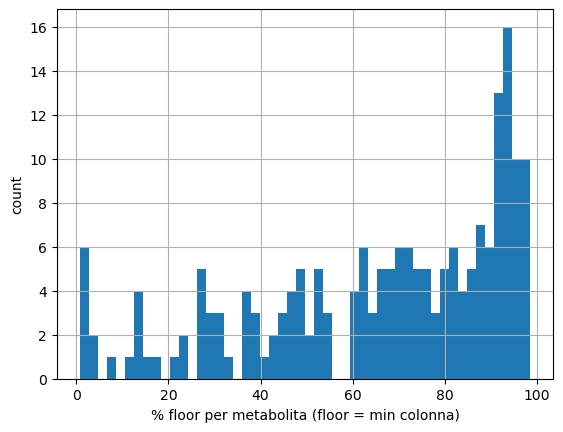

,pct_floor
143390,98.604269
154201,98.193760
88906,98.152709
173108,97.906404
105612,97.824302
133194,97.783251
132791,97.413793
134424,97.126437
122834,97.044335
132322,96.798030


In [176]:
# =========================
# [10] MINI-REPORT EDA: distribuzione %floor + sanity check
# =========================
print("Pazienti:", df_eda["Code"].nunique())
print("Time:", sorted(df_eda["Time"].unique()))
print("Righe:", len(df_eda))

plt.figure()
pct_floor.hist(bins=50)
plt.xlabel("% floor per metabolita (floor = min colonna)")
plt.ylabel("count")
plt.show()

# esempio: 10 metaboliti con più floor
top_floor = pct_floor.sort_values(ascending=False).head(10)
display(top_floor.to_frame("pct_floor"))

## Correlazione 

In [177]:
# =========================
# [C1] PREPARA MATRICE METABOLITI PER CORRELAZIONE
# =========================
import numpy as np
import pandas as pd

# solo metaboliti finali della parte EDA
X = df_eda[met_cols_eda].apply(pd.to_numeric, errors="coerce").copy()

print("Shape X:", X.shape)
print("Numero metaboliti:", X.shape[1])
print("NaN totali:", int(np.isnan(X.to_numpy()).sum()))

Shape X: (2436, 16)
Numero metaboliti: 16
NaN totali: 0


In [178]:
# =========================
# [C2] LOG10 DEI METABOLITI (valori <= 0 -> NaN)
# =========================
X_log = np.log10(X.where(X > 0, np.nan))

print("Shape X_log:", X_log.shape)
print("NaN totali dopo log10:", int(np.isnan(X_log.to_numpy()).sum()))
print("Metaboliti con almeno 1 valore valido dopo log10:", int((X_log.notna().sum(axis=0) > 0).sum()))

Shape X_log: (2436, 16)
NaN totali dopo log10: 0
Metaboliti con almeno 1 valore valido dopo log10: 16


In [179]:
# =========================
# [C3] MATRICE DI CORRELAZIONE
# =========================
import matplotlib.pyplot as plt

METHOD = "spearman"   # consigliato qui

corr = X_log.corr(method=METHOD)



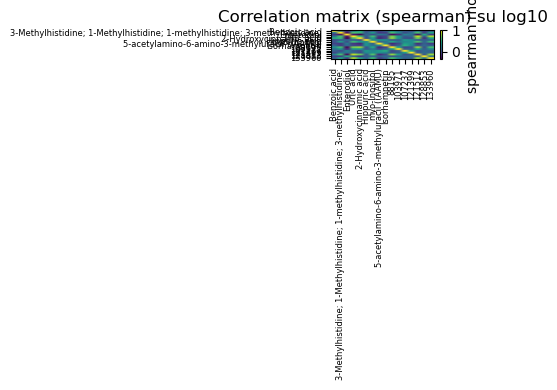

In [180]:
# =========================
# [C4] HEATMAP DELLA MATRICE DI CORRELAZIONE
# =========================
plt.figure(figsize=(5, 4))
plt.imshow(corr.values, aspect="auto")
plt.colorbar(label=f"{METHOD} rho")
plt.title(f"Correlation matrix ({METHOD}) su log10")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=6)
plt.yticks(range(len(corr.index)), corr.index, fontsize=6)
plt.tight_layout()
plt.show()

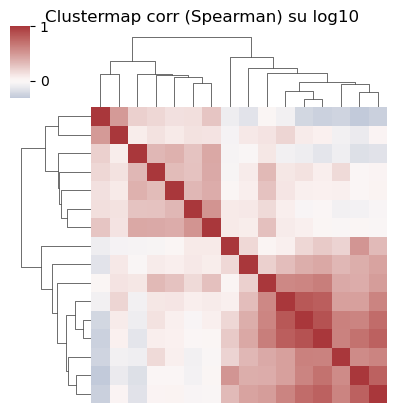

In [181]:
# =========================
# [C5] CLUSTERMAP DELLA CORRELAZIONE
# =========================
import seaborn as sns
import matplotlib.pyplot as plt

sns.clustermap(
    corr,
    figsize=(4, 4),
    cmap="vlag",
    center=0,
    linewidths=0,
    xticklabels=False,
    yticklabels=False
)
plt.suptitle("Clustermap corr (Spearman) su log10", y=1.02)
plt.show()

In [182]:
# =========================
# [C6] ESTRAI LE COPPIE DI METABOLITI PIÙ CORRELATE
# =========================
TH = 0.8   # soglia su |rho|

c = corr.copy()

# upper triangle senza diagonale
mask = np.triu(np.ones(c.shape, dtype=bool), k=1)

i, j = np.where(mask)
rho = c.to_numpy()[i, j]

vals = pd.DataFrame({
    "met1": c.index.to_numpy()[i],
    "met2": c.columns.to_numpy()[j],
    "rho": rho
})

vals = vals.dropna(subset=["rho"]).copy()
vals["abs_rho"] = vals["rho"].abs()
vals = vals.sort_values("abs_rho", ascending=False).reset_index(drop=True)

print(f"Coppie totali (uniche): {vals.shape[0]}")
print(f"Coppie con |rho| > {TH}: {int((vals['abs_rho'] > TH).sum())}")

display(vals.head(20))

Coppie totali (uniche): 120
Coppie con |rho| > 0.8: 2


,met1,met2,rho,abs_rho
0,Uric acid,121512,0.864476,0.864476
1,Uric acid,133960,0.825727,0.825727
2,121512,133960,0.796143,0.796143
3,2-Hydroxycinnamic acid,88195,0.782559,0.782559
4,88195,121512,0.781937,0.781937
5,Uric acid,88195,0.724956,0.724956
6,2-Hydroxycinnamic acid,121512,0.697858,0.697858
7,myo-Inositol,121512,0.638866,0.638866
8,3-Methylhistidine; 1-Methylhistidine; 1-methyl...,Uric acid,0.618866,0.618866
9,3-Methylhistidine; 1-Methylhistidine; 1-methyl...,121512,0.614120,0.614120


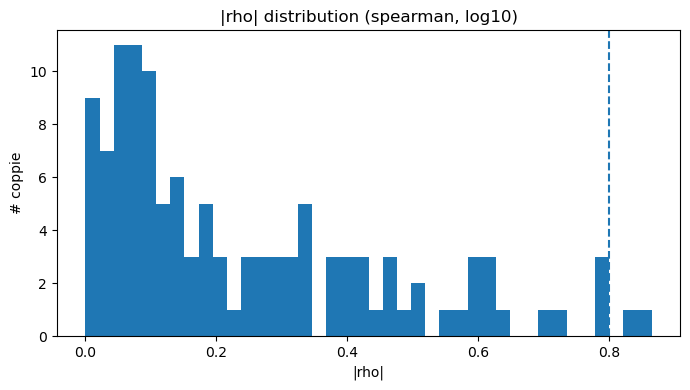

In [183]:
# =========================
# [C7] ISTOGRAMMA DELLE |CORRELAZIONI|
# =========================
plt.figure(figsize=(7, 4))
plt.hist(vals["abs_rho"].dropna().values, bins=40)
plt.axvline(TH, linestyle="--")
plt.title(f"|rho| distribution ({METHOD}, log10)")
plt.xlabel("|rho|")
plt.ylabel("# coppie")
plt.tight_layout()
plt.show()

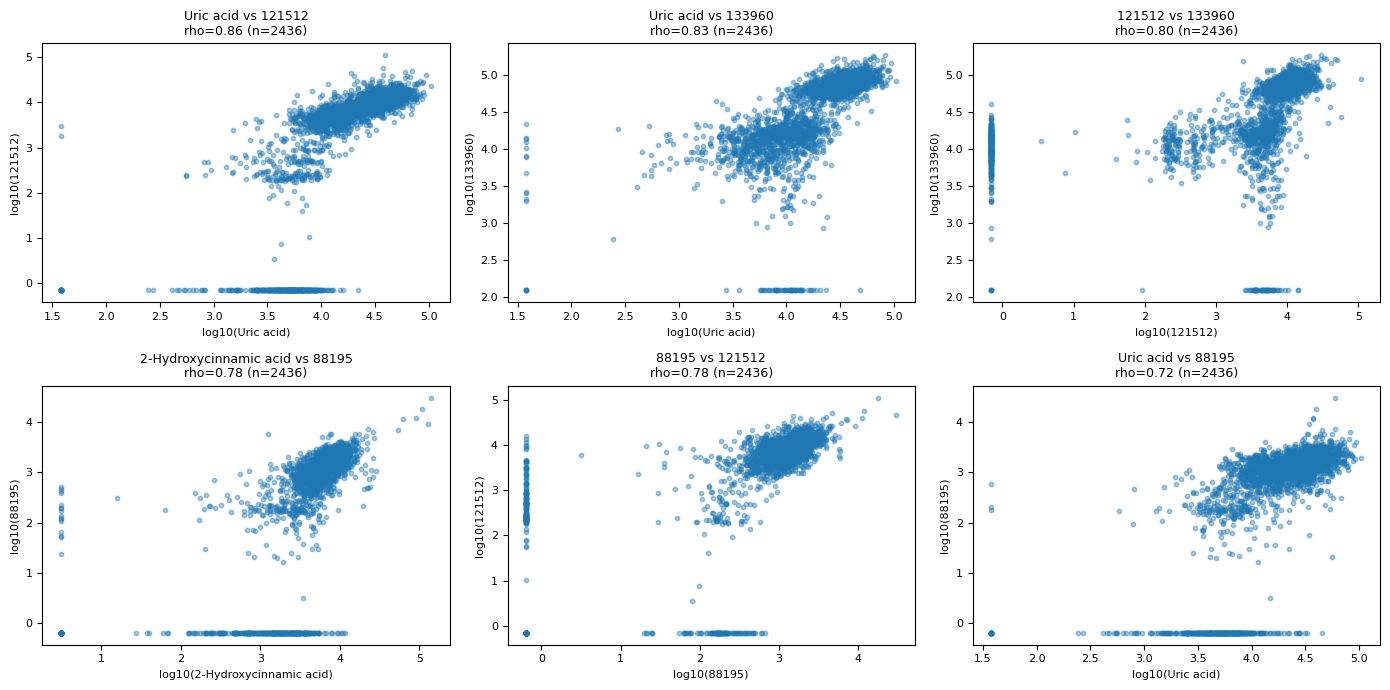

In [184]:
# =========================
# [C9] SCATTER DELLE COPPIE PIÙ CORRELATE
# =========================
N_SCATTER = 6

pairs_to_plot = vals.sort_values("abs_rho", ascending=False).head(N_SCATTER).copy()

fig, axes = plt.subplots(2, int(np.ceil(N_SCATTER / 2)), figsize=(14, 7))
axes = axes.ravel()

for k, row in enumerate(pairs_to_plot.itertuples(index=False)):
    m1, m2, rho, abs_rho = row.met1, row.met2, row.rho, row.abs_rho
    ax = axes[k]

    x = X_log[m1]
    y = X_log[m2]
    ok = x.notna() & y.notna()

    ax.scatter(x[ok].values, y[ok].values, s=10, alpha=0.4)
    ax.set_title(f"{m1} vs {m2}\nrho={rho:.2f} (n={int(ok.sum())})", fontsize=9)
    ax.set_xlabel(f"log10({m1})", fontsize=8)
    ax.set_ylabel(f"log10({m2})", fontsize=8)
    ax.tick_params(labelsize=8)

for j in range(k + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## two model


In [185]:
# =========================
# [TM1] SETUP + FUNZIONI UTILI (two-model)
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

TIMES = [1, 2, 3, 4]
RTOL, ATOL = 1e-6, 1e-12
Q_FDR = 0.05

# QC (solo per evitare modelli instabili, NON elimina dal dataset finale EDA)
MIN_PREV = 0.02          # prevalenza detect troppo bassa -> separazione
MAX_PREV = 1
MIN_DETECT_TOTAL = 80    # n osservazioni detect=1
MIN_DETECT_PAT   = 40    # n pazienti con almeno 1 detect=1
MIN_Y_UNIQUE     = 5     # valori unici y (log10)
MIN_SUBJ_LMM     = 20    # soggetti min per mixedlm

def fdr_bh(p):
    p = pd.to_numeric(p, errors="coerce")
    out = pd.Series(np.nan, index=p.index, dtype=float)
    m = p.notna() & np.isfinite(p) & (p >= 0) & (p <= 1)
    if m.sum() > 0:
        out.loc[m] = multipletests(p.loc[m].values, method="fdr_bh")[1]
    return out

def p_int_min(pvalues, prefix):
    vals = []
    for k, v in pvalues.items():
        if str(k).startswith(prefix) and np.isfinite(v):
            vals.append(float(v))
    return float(np.min(vals)) if len(vals) > 0 else np.nan

def classify_bucket(det_sig, int_sig):
    if det_sig and int_sig: return "Both"
    if det_sig: return "Detect only"
    if int_sig: return "Intensity only"
    return "Not significant"

def fit_lmm_safe(d_pos):
    # mixedlm a volte converge solo con certi ottimizzatori
    for method in ["lbfgs", "powell", "nm"]:
        try:
            model = smf.mixedlm(
                "y ~ FI_between + FI_within * C(Time)",
                data=d_pos,
                groups=d_pos["Code"]
            )
            fit = model.fit(reml=True, method=method, disp=False)
            return fit, method
        except Exception:
            continue
    return None, None

In [186]:
# =========================
# [TM2] PREPARA BASE (df_eda) + FI_between / FI_within + floors
# =========================
# check: ci aspettiamo già 609 pazienti e 4 timepoint
base = df_eda[["Code", "Time", "FI"] + met_cols_eda].copy()

base["Code"] = pd.to_numeric(base["Code"], errors="coerce").astype(int)
base["Time"] = pd.to_numeric(base["Time"], errors="coerce").astype(int)
base["FI"]   = pd.to_numeric(base["FI"], errors="coerce").clip(0, 1)

base = base.dropna(subset=["Code", "Time", "FI"]).copy()
base = base[base["Time"].isin(TIMES)].sort_values(["Code","Time"]).copy()

# (ridondante ma safe) tieni solo pazienti completi T1..T4
n_tp = base.groupby("Code")["Time"].nunique()
keep_codes = n_tp[n_tp == len(TIMES)].index
base = base[base["Code"].isin(keep_codes)].copy()

# between / within FI
fi_mean = base.groupby("Code")["FI"].mean()
base["FI_between"] = base["Code"].map(fi_mean)
base["FI_within"]  = base["FI"] - base["FI_between"]

# floor per metabolita = min colonna (su df_eda già pulito)
floors = base[met_cols_eda].min(axis=0)

print("Righe:", len(base))
print("Pazienti:", base["Code"].nunique())
print("Metaboliti:", len(met_cols_eda))
print("Time:", sorted(base["Time"].unique()))

Righe: 2436
Pazienti: 609
Metaboliti: 16
Time: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [187]:
# =========================
# [TM3] MODELLO 1: DETECTION (GEE binomiale + fallback GLM cluster)
# Detected ~ FI_between + FI_within * C(Time)
# =========================
rows = []
skipped_prev = 0
failed = 0

for m in met_cols_eda:
    d = base[["Code","Time","FI_between","FI_within",m]].copy()
    fl = float(floors[m])

    # detected = diverso dal floor (con tolleranza)
    x = d[m].to_numpy(dtype=float)
    d["Detected"] = (~np.isclose(x, fl, rtol=RTOL, atol=ATOL)).astype(int)

    prev = float(d["Detected"].mean())
    n_detect_total = int(d["Detected"].sum())
    n_pat_detect1  = int(d.loc[d["Detected"] == 1, "Code"].nunique())

    # evita separazione quasi perfetta (modello che esplode)
    if (prev < MIN_PREV) or (prev > MAX_PREV) or (d["Detected"].nunique() < 2):
        skipped_prev += 1
        rows.append({
            "metabolite": m,
            "prev_detect": prev,
            "n_detect_total": n_detect_total,
            "n_pat_detect1": n_pat_detect1,
            "beta_between_det": np.nan, "p_between_det": np.nan,
            "beta_within_det":  np.nan, "p_within_det":  np.nan,
            "p_intMin_det":     np.nan,
            "detect_model_used":"skipped_prev"
        })
        continue

    b_bet = p_bet = b_wit = p_wit = p_int = np.nan
    used_model = "failed"

    # GEE (Exchangeable) -> standard per longitudinal binary
    try:
        fit = smf.gee(
            "Detected ~ FI_between + FI_within * C(Time)",
            groups="Code",
            data=d,
            family=sm.families.Binomial(),
            cov_struct=sm.cov_struct.Exchangeable()
        ).fit(maxiter=200)

        b_bet = float(fit.params.get("FI_between", np.nan))
        p_bet = float(fit.pvalues.get("FI_between", np.nan))
        b_wit = float(fit.params.get("FI_within", np.nan))
        p_wit = float(fit.pvalues.get("FI_within", np.nan))
        p_int = p_int_min(fit.pvalues, prefix="FI_within:C(Time)")
        used_model = "GEE_binom_EXCH"

    except Exception:
        # fallback: GLM binomiale con SE cluster su paziente
        try:
            fit = smf.glm(
                "Detected ~ FI_between + FI_within * C(Time)",
                data=d,
                family=sm.families.Binomial()
            ).fit(cov_type="cluster", cov_kwds={"groups": d["Code"]})

            b_bet = float(fit.params.get("FI_between", np.nan))
            p_bet = float(fit.pvalues.get("FI_between", np.nan))
            b_wit = float(fit.params.get("FI_within", np.nan))
            p_wit = float(fit.pvalues.get("FI_within", np.nan))
            p_int = p_int_min(fit.pvalues, prefix="FI_within:C(Time)")
            used_model = "GLM_binom_cluster"

        except Exception:
            failed += 1

    rows.append({
        "metabolite": m,
        "prev_detect": prev,
        "n_detect_total": n_detect_total,
        "n_pat_detect1": n_pat_detect1,
        "beta_between_det": b_bet, "p_between_det": p_bet,
        "beta_within_det":  b_wit, "p_within_det":  p_wit,
        "p_intMin_det":     p_int,
        "detect_model_used":used_model
    })

det = pd.DataFrame(rows)

# FDR separata su 3 famiglie di test
det["q_between_det"] = fdr_bh(det["p_between_det"])
det["q_within_det"]  = fdr_bh(det["p_within_det"])
det["q_intMin_det"]  = fdr_bh(det["p_intMin_det"])

det["q_det_min"] = det[["q_between_det","q_within_det","q_intMin_det"]].min(axis=1, skipna=True)
det["sig_det"] = det["q_det_min"] < Q_FDR

print("Detect — skipped prev:", skipped_prev, "| failed:", failed)
print("Detect — significativi (q_det_min < 0.05):", int(det["sig_det"].sum()))
display(det.sort_values(["sig_det","q_det_min"], ascending=[False, True]).head(20))

/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/genmod/families/links.py:240: RuntimeWarning:

overflow encountered in square

/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning:

overflow encountered in exp

/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/genmod/families/links.py:239: RuntimeWarning:

overflow encountered in exp

/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/genmod/families/links.py:240: RuntimeWarning:

invalid value encountered in divide

/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning:

overflow encountered in exp

/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/genmod/families/links.py:239: RuntimeWarning:

overflow encountered in exp

/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/genmod/families/links.py:240: RuntimeWarning:

inv

Detect — skipped prev: 0 | failed: 0
Detect — significativi (q_det_min < 0.05): 5


,metabolite,prev_detect,n_detect_total,n_pat_detect1,beta_between_det,p_between_det,beta_within_det,p_within_det,p_intMin_det,detect_model_used,q_between_det,q_within_det,q_intMin_det,q_det_min,sig_det
1,3-Methylhistidine; 1-Methylhistidine; 1-methyl...,0.876026,2134,609,-0.253042,0.837427,7.916558,0.000777,3.037637e-07,GEE_binom_EXCH,0.946952,0.010883,0.000004,0.000004,True
6,myo-Inositol,0.984401,2398,609,-0.327533,0.901805,6.565780,0.153841,1.240755e-06,GEE_binom_EXCH,0.946952,0.326980,0.000009,0.000009,True
5,Hippuric acid,0.981117,2390,609,-1.078644,0.613436,5.865440,0.183317,4.057851e-06,GEE_binom_EXCH,0.946952,0.326980,0.000019,0.000019,True
8,Isorhamnetin,0.981117,2390,609,-1.525065,0.516774,4.715885,0.286286,1.033623e-05,GEE_binom_EXCH,0.946952,0.400800,0.000036,0.000036,True
15,133960,0.975780,2377,609,0.157523,0.946952,5.019975,0.188703,4.404906e-05,GEE_binom_EXCH,0.946952,0.326980,0.000123,0.000123,True
2,Enterodiol,0.858785,2092,609,-1.730963,0.058535,-7.637738,0.044842,4.761617e-02,GEE_binom_EXCH,0.409746,0.313895,0.093160,0.093160,False
4,2-Hydroxycinnamic acid,0.966749,2355,609,-1.350507,0.458968,-5.580742,0.117789,5.988846e-02,GEE_binom_EXCH,0.946952,0.326980,0.093160,0.093160,False
9,88195,0.842365,2052,609,-2.164474,0.037069,-13.902623,0.210202,4.105148e-02,GEE_binom_EXCH,0.409746,0.326980,0.093160,0.093160,False
11,107237,0.963875,2348,609,-0.248682,0.890381,6.717126,0.118294,5.975242e-02,GEE_binom_EXCH,0.946952,0.326980,0.093160,0.093160,False
10,103971,0.873153,2127,608,0.134548,0.916693,3.584842,0.492327,7.185138e-02,GEE_binom_EXCH,0.946952,0.492327,0.100592,0.100592,False


In [188]:
# =========================
# [TM4] MODELLO 2: INTENSITY (LMM su log10, solo detect=1)
# y ~ FI_between + FI_within * C(Time) + (1 | Code)
# =========================
rows = []
skipped_qc = 0
failed = 0

for m in met_cols_eda:
    d = base[["Code","Time","FI_between","FI_within",m]].copy()
    fl = float(floors[m])

    x = d[m].to_numpy(dtype=float)
    d["Detected"] = (~np.isclose(x, fl, rtol=RTOL, atol=ATOL)).astype(int)

    n_detect_total = int(d["Detected"].sum())
    n_pat_detect1  = int(d.loc[d["Detected"] == 1, "Code"].nunique())

    d_pos = d[d["Detected"] == 1].copy()
    d_pos["y"] = np.log10(d_pos[m].where(d_pos[m] > 0, np.nan))
    d_pos = d_pos.dropna(subset=["y"]).copy()

    ok = (
        (n_detect_total >= MIN_DETECT_TOTAL) and
        (n_pat_detect1  >= MIN_DETECT_PAT) and
        (d_pos["y"].nunique() >= MIN_Y_UNIQUE) and
        (d_pos["Code"].nunique() >= MIN_SUBJ_LMM)
    )

    if not ok:
        skipped_qc += 1
        rows.append({
            "metabolite": m,
            "beta_between_int": np.nan, "p_between_int": np.nan,
            "beta_within_int":  np.nan, "p_within_int":  np.nan,
            "p_intMin_int":     np.nan,
            "int_model_used":"skipped_qc"
        })
        continue

    fit, used_method = fit_lmm_safe(d_pos)
    if fit is None:
        failed += 1
        rows.append({
            "metabolite": m,
            "beta_between_int": np.nan, "p_between_int": np.nan,
            "beta_within_int":  np.nan, "p_within_int":  np.nan,
            "p_intMin_int":     np.nan,
            "int_model_used":"failed"
        })
        continue

    rows.append({
        "metabolite": m,
        "beta_between_int": float(fit.params.get("FI_between", np.nan)),
        "p_between_int":    float(fit.pvalues.get("FI_between", np.nan)),
        "beta_within_int":  float(fit.params.get("FI_within", np.nan)),
        "p_within_int":     float(fit.pvalues.get("FI_within", np.nan)),
        "p_intMin_int":     p_int_min(fit.pvalues, prefix="FI_within:C(Time)"),
        "int_model_used":   f"LMM_{used_method}"
    })

int_tab = pd.DataFrame(rows)

int_tab["q_between_int"] = fdr_bh(int_tab["p_between_int"])
int_tab["q_within_int"]  = fdr_bh(int_tab["p_within_int"])
int_tab["q_intMin_int"]  = fdr_bh(int_tab["p_intMin_int"])

int_tab["q_int_min"] = int_tab[["q_between_int","q_within_int","q_intMin_int"]].min(axis=1, skipna=True)
int_tab["sig_int"] = int_tab["q_int_min"] < Q_FDR

print("Intensity — skipped QC:", skipped_qc, "| failed:", failed)
print("Intensity — significativi (q_int_min < 0.05):", int(int_tab["sig_int"].sum()))
display(int_tab.sort_values(["sig_int","q_int_min"], ascending=[False, True]).head(20))

/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning:

Random effects covariance is singular

/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning:

Random effects covariance is singular

/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning:

Random effects covariance is singular

/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning:

The MLE may be on the boundary of the parameter space.

/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning:

Random effects covariance is singular

/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning:

Random effects covariance is singular

/opt/minic

Intensity — skipped QC: 0 | failed: 0
Intensity — significativi (q_int_min < 0.05): 2


,metabolite,beta_between_int,p_between_int,beta_within_int,p_within_int,p_intMin_int,int_model_used,q_between_int,q_within_int,q_intMin_int,q_int_min,sig_int
1,3-Methylhistidine; 1-Methylhistidine; 1-methyl...,0.593501,0.000064,0.348387,0.416054,0.596107,LMM_lbfgs,0.001030,0.965731,0.596107,0.001030,True
6,myo-Inositol,0.285068,0.000469,-0.065570,0.793282,0.138170,LMM_lbfgs,0.003753,0.965731,0.303053,0.003753,True
10,103971,0.812915,0.023662,0.733696,0.389630,0.156222,LMM_lbfgs,0.083220,0.965731,0.303053,0.083220,False
11,107237,0.291227,0.026006,0.121253,0.700040,0.092675,LMM_lbfgs,0.083220,0.965731,0.247133,0.083220,False
12,121399,0.408043,0.017561,0.137172,0.702760,0.395714,LMM_lbfgs,0.083220,0.965731,0.487032,0.083220,False
3,Uric acid,0.015737,0.910530,-0.018440,0.964140,0.022455,LMM_lbfgs,0.985499,0.965731,0.179642,0.179642,False
4,2-Hydroxycinnamic acid,0.024020,0.851232,-0.160933,0.691907,0.013704,LMM_lbfgs,0.985499,0.965731,0.179642,0.179642,False
15,133960,-0.070833,0.608686,0.035985,0.930934,0.033720,LMM_lbfgs,0.940706,0.965731,0.179838,0.179838,False
2,Enterodiol,0.263672,0.120723,0.883488,0.119680,0.060216,LMM_lbfgs,0.275939,0.957440,0.240862,0.240862,False
5,Hippuric acid,-0.323296,0.113544,-0.021730,0.965731,0.088482,LMM_lbfgs,0.275939,0.965731,0.247133,0.247133,False


In [189]:
# =========================
# [TM5] MERGE RISULTATI + BUCKET + TABELLA FINALE
# =========================
final = det.merge(int_tab, on="metabolite", how="left")

final["bucket"] = final.apply(
    lambda r: classify_bucket(bool(r.get("sig_det", False)), bool(r.get("sig_int", False))),
    axis=1
)

final["q_best"] = final[["q_det_min","q_int_min"]].min(axis=1, skipna=True)
final["sig_any"] = (final["q_best"] < Q_FDR)

print("Significativi (any):", int(final["sig_any"].sum()))

cols_show = [
    "metabolite",
    "prev_detect", "n_detect_total", "n_pat_detect1",
    "q_det_min", "q_int_min", "q_best",
    "bucket",
    "detect_model_used", "int_model_used"
]

display(final.sort_values(["sig_any","q_best"], ascending=[False, True])[cols_show].head(60))

Significativi (any): 5


,metabolite,prev_detect,n_detect_total,n_pat_detect1,q_det_min,q_int_min,q_best,bucket,detect_model_used,int_model_used
1,3-Methylhistidine; 1-Methylhistidine; 1-methyl...,0.876026,2134,609,0.000004,0.001030,0.000004,Both,GEE_binom_EXCH,LMM_lbfgs
6,myo-Inositol,0.984401,2398,609,0.000009,0.003753,0.000009,Both,GEE_binom_EXCH,LMM_lbfgs
5,Hippuric acid,0.981117,2390,609,0.000019,0.247133,0.000019,Detect only,GEE_binom_EXCH,LMM_lbfgs
8,Isorhamnetin,0.981117,2390,609,0.000036,0.487032,0.000036,Detect only,GEE_binom_EXCH,LMM_lbfgs
15,133960,0.975780,2377,609,0.000123,0.179838,0.000123,Detect only,GEE_binom_EXCH,LMM_lbfgs
10,103971,0.873153,2127,608,0.100592,0.083220,0.083220,Not significant,GEE_binom_EXCH,LMM_lbfgs
11,107237,0.963875,2348,609,0.093160,0.083220,0.083220,Not significant,GEE_binom_EXCH,LMM_lbfgs
12,121399,0.979885,2387,609,0.124217,0.083220,0.083220,Not significant,GEE_binom_EXCH,LMM_lbfgs
2,Enterodiol,0.858785,2092,609,0.093160,0.240862,0.093160,Not significant,GEE_binom_EXCH,LMM_lbfgs
4,2-Hydroxycinnamic acid,0.966749,2355,609,0.093160,0.179642,0.093160,Not significant,GEE_binom_EXCH,LMM_lbfgs


Plot metaboliti: 5


/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning:

Random effects covariance is singular



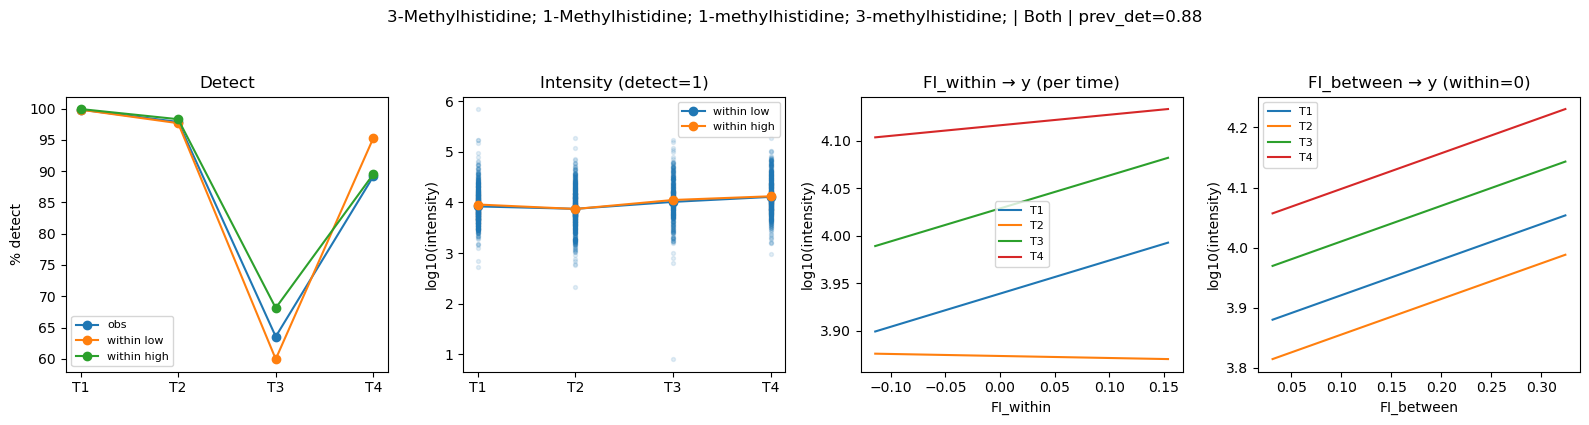

/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning:

Random effects covariance is singular



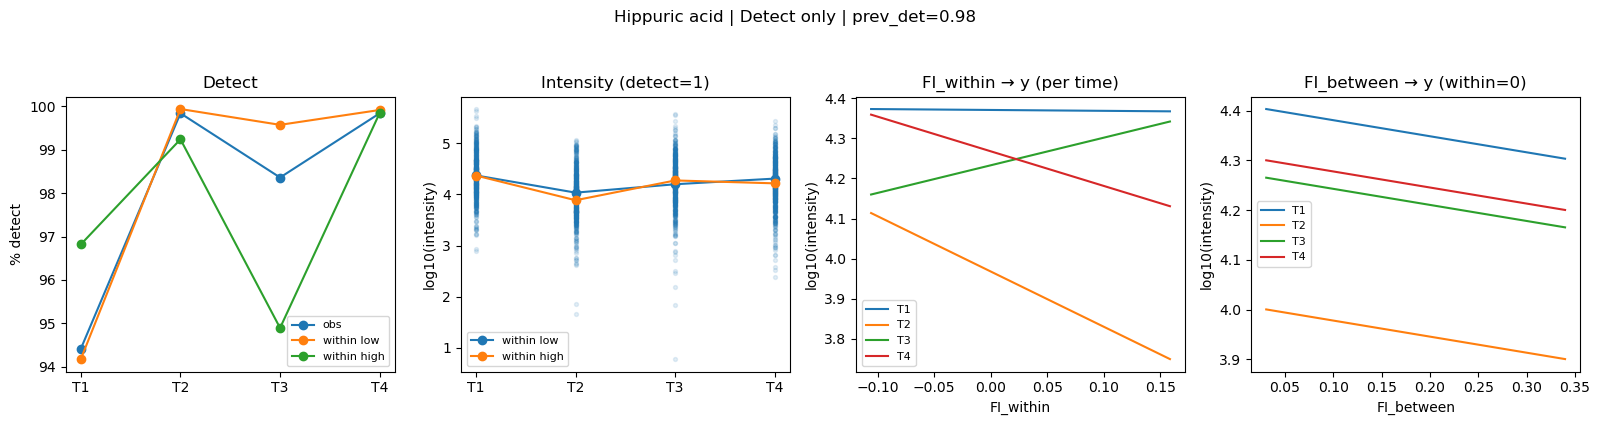

/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning:

Random effects covariance is singular

/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning:

The MLE may be on the boundary of the parameter space.



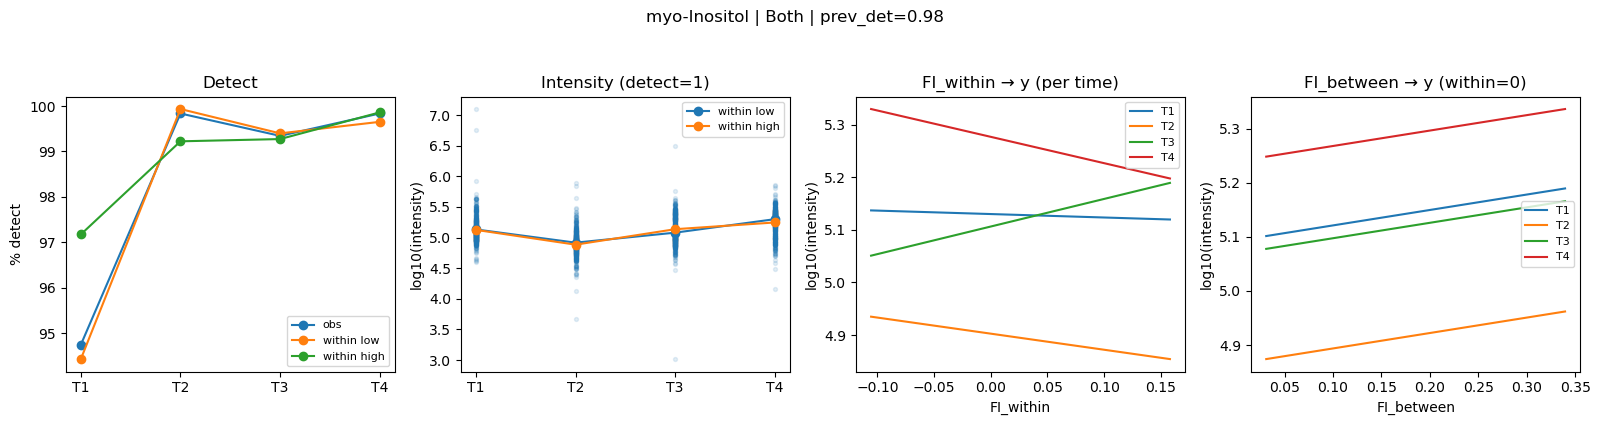

/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning:

Random effects covariance is singular

/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning:

MixedLM optimization failed, trying a different optimizer may help.

/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning:

Gradient optimization failed, |grad| = 180.268457



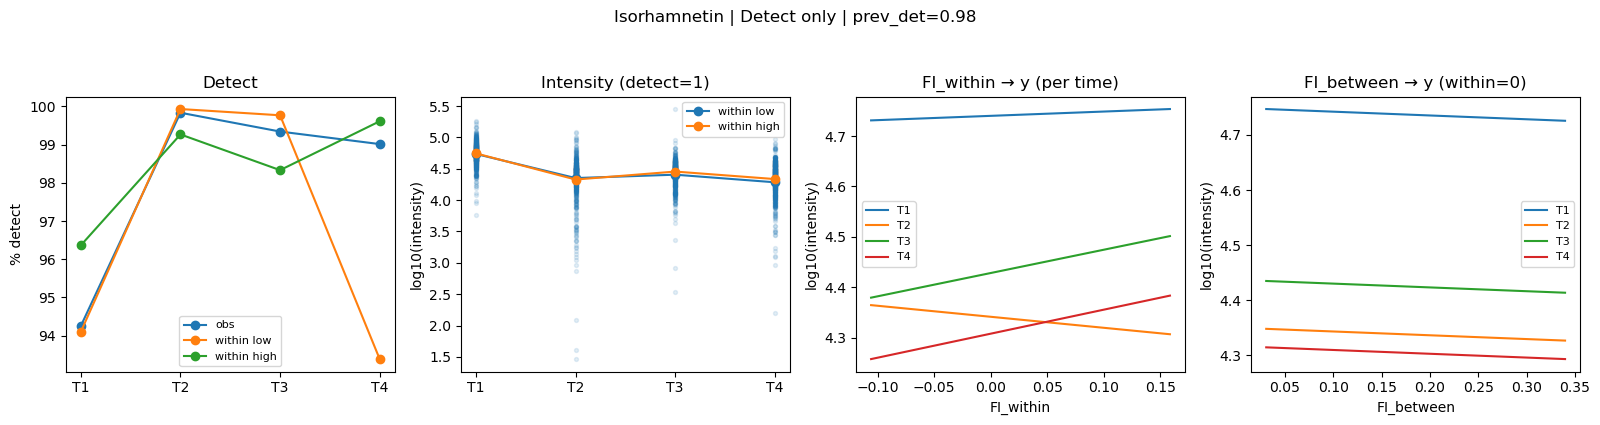

/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning:

Random effects covariance is singular



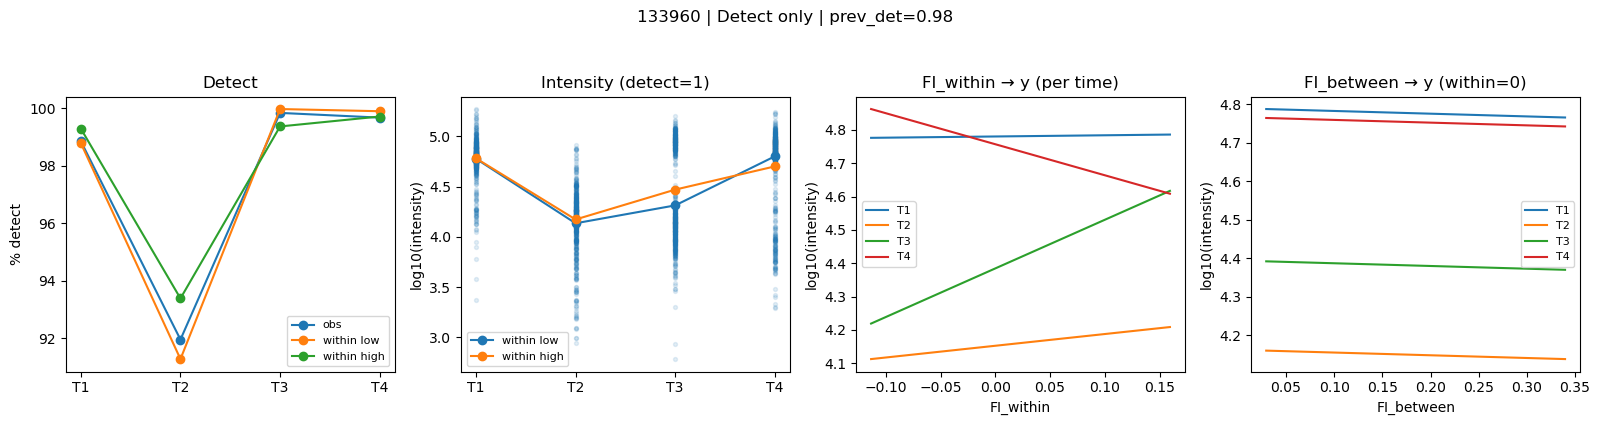

In [190]:
# =========================
# [TM6] PLOT (solo per metaboliti significativi) — detect + intensity + curve
# =========================
MAX_PLOTS = 25
sel = final.loc[final["sig_any"], "metabolite"].tolist()[:MAX_PLOTS]
print("Plot metaboliti:", len(sel))

for m in sel:
    d = base[["Code","Time","FI_between","FI_within",m]].copy()
    fl = float(floors[m])

    x = d[m].to_numpy(dtype=float)
    d["Detected"] = (~np.isclose(x, fl, rtol=RTOL, atol=ATOL)).astype(int)
    d["y"] = np.log10(d[m].where(d[m] > 0, np.nan))

    prev = float(d["Detected"].mean())

    d_pos = d[(d["Detected"] == 1) & d["y"].notna()].copy()
    time_levels_pos = sorted(d_pos["Time"].unique())

    wit_lo = float(d["FI_within"].quantile(0.10))
    wit_hi = float(d["FI_within"].quantile(0.90))

    # fit detect
    fit_det = None
    if (MIN_PREV <= prev <= MAX_PREV) and (d["Detected"].nunique() >= 2):
        try:
            fit_det = smf.gee(
                "Detected ~ FI_between + FI_within * C(Time)",
                groups="Code",
                data=d,
                family=sm.families.Binomial(),
                cov_struct=sm.cov_struct.Exchangeable()
            ).fit(maxiter=200)
        except Exception:
            try:
                fit_det = smf.glm(
                    "Detected ~ FI_between + FI_within * C(Time)",
                    data=d,
                    family=sm.families.Binomial()
                ).fit(cov_type="cluster", cov_kwds={"groups": d["Code"]})
            except Exception:
                fit_det = None

    # fit intensity
    fit_int = None
    if (
        d_pos.shape[0] >= MIN_DETECT_TOTAL and
        d_pos["Code"].nunique() >= MIN_SUBJ_LMM and
        d_pos["y"].nunique() >= MIN_Y_UNIQUE
    ):
        fit_int, _ = fit_lmm_safe(d_pos)

    fig = plt.figure(figsize=(16, 4))

    # A) detect nel tempo
    ax1 = plt.subplot(1, 4, 1)
    det_obs = d.groupby("Time")["Detected"].mean().reindex(TIMES)
    ax1.plot(TIMES, det_obs.values * 100, marker="o", label="obs")

    if fit_det is not None:
        b_fix = float(d["FI_between"].median())
        grid = pd.DataFrame({
            "FI_between": [b_fix] * (2 * len(TIMES)),
            "FI_within": [wit_lo] * len(TIMES) + [wit_hi] * len(TIMES),
            "Time": TIMES + TIMES
        })
        try:
            pr = fit_det.predict(grid)
            ax1.plot(TIMES, pr[:len(TIMES)] * 100, marker="o", label="within low")
            ax1.plot(TIMES, pr[len(TIMES):] * 100, marker="o", label="within high")
        except Exception:
            pass

    ax1.set_title("Detect")
    ax1.set_xticks(TIMES)
    ax1.set_xticklabels([f"T{t}" for t in TIMES])
    ax1.set_ylabel("% detect")
    ax1.legend(fontsize=8)

    # B) intensity nel tempo
    ax2 = plt.subplot(1, 4, 2)
    ax2.scatter(d_pos["Time"], d_pos["y"], s=8, alpha=0.12)
    if fit_int is not None and len(time_levels_pos) > 0:
        b_fix = float(d_pos["FI_between"].median())
        grid2 = pd.DataFrame({
            "FI_between": [b_fix] * (2 * len(time_levels_pos)),
            "FI_within": [wit_lo] * len(time_levels_pos) + [wit_hi] * len(time_levels_pos),
            "Time": time_levels_pos + time_levels_pos
        })
        try:
            yhat = fit_int.predict(exog=grid2)
            ax2.plot(time_levels_pos, yhat[:len(time_levels_pos)], marker="o", label="within low")
            ax2.plot(time_levels_pos, yhat[len(time_levels_pos):], marker="o", label="within high")
            ax2.legend(fontsize=8)
        except Exception:
            pass

    ax2.set_title("Intensity (detect=1)")
    ax2.set_xticks(TIMES)
    ax2.set_xticklabels([f"T{t}" for t in TIMES])
    ax2.set_ylabel("log10(intensity)")

    # C) FI_within -> y (per time)
    ax3 = plt.subplot(1, 4, 3)
    if fit_int is None or len(time_levels_pos) == 0:
        ax3.text(0.5, 0.5, "NA", ha="center", va="center")
        ax3.set_axis_off()
    else:
        w_grid = np.linspace(
            float(d_pos["FI_within"].quantile(0.01)),
            float(d_pos["FI_within"].quantile(0.99)),
            120
        )
        b_fix = float(d_pos["FI_between"].median())
        for t in time_levels_pos:
            grid_t = pd.DataFrame({"FI_between": b_fix, "FI_within": w_grid, "Time": t})
            try:
                ax3.plot(w_grid, fit_int.predict(exog=grid_t), label=f"T{t}")
            except Exception:
                pass
        ax3.set_title("FI_within → y (per time)")
        ax3.set_xlabel("FI_within")
        ax3.set_ylabel("log10(intensity)")
        ax3.legend(fontsize=8)

    # D) FI_between -> y (within=0)
    ax4 = plt.subplot(1, 4, 4)
    if fit_int is None or len(time_levels_pos) == 0:
        ax4.text(0.5, 0.5, "NA", ha="center", va="center")
        ax4.set_axis_off()
    else:
        b_grid = np.linspace(
            float(d_pos["FI_between"].quantile(0.01)),
            float(d_pos["FI_between"].quantile(0.99)),
            120
        )
        w_fix = 0.0
        for t in time_levels_pos:
            grid_t = pd.DataFrame({"FI_between": b_grid, "FI_within": w_fix, "Time": t})
            try:
                ax4.plot(b_grid, fit_int.predict(exog=grid_t), label=f"T{t}")
            except Exception:
                pass
        ax4.set_title("FI_between → y (within=0)")
        ax4.set_xlabel("FI_between")
        ax4.set_ylabel("log10(intensity)")
        ax4.legend(fontsize=8)

    bucket = final.loc[final["metabolite"] == m, "bucket"].iloc[0]
    fig.suptitle(f"{m} | {bucket} | prev_det={prev:.2f}", y=1.05)
    plt.tight_layout()
    plt.show()

## Spline mixed model

In [224]:
# =========================
# [FIM1] IMPORT + SETTINGS
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from patsy import bs

TIMES = [1,2,3,4]
TIME_TO_YEARS = {1: 0.0, 2: 2.0, 3: 4.0, 4: 8.0}

FRAIL_THR = 0.25
Q_FDR = 0.05

SPLINE_DF = 3
EPS = 1e-9  # per log10(x + EPS) anche se x=0

def fdr_bh(p):
    p = pd.to_numeric(p, errors="coerce")
    out = pd.Series(np.nan, index=p.index, dtype=float)
    m = p.notna() & np.isfinite(p) & (p >= 0) & (p <= 1)
    if m.sum() > 0:
        out.loc[m] = multipletests(p.loc[m].values, method="fdr_bh")[1]
    return out

In [225]:
# =========================
# [FIM2] BASE LONG: FI + tempo reale (anni) + gruppo ever/never
# Usa df_eda e met_cols_eda (già puliti, con floor inclusi)
# =========================
# NB: se i tuoi metaboliti finali non sono met_cols_eda, cambia qui.
mets = list(met_cols_eda)

base = df_eda[["Code","Time","FI"] + mets].copy()

base["Code"] = pd.to_numeric(base["Code"], errors="coerce").astype(int)
base["Time"] = pd.to_numeric(base["Time"], errors="coerce").astype(int)
base["FI"]   = pd.to_numeric(base["FI"], errors="coerce")

base = base.dropna(subset=["Code","Time","FI"]).copy()
base = base[base["Time"].isin(TIMES)].sort_values(["Code","Time"]).copy()

# tieni solo pazienti completi T1..T4
n_tp = base.groupby("Code")["Time"].nunique()
keep_codes = n_tp[n_tp == len(TIMES)].index
base = base[base["Code"].isin(keep_codes)].copy()

# tempo reale
base["t_years"] = base["Time"].map(TIME_TO_YEARS).astype(float)
base["t"] = base["t_years"] / base["t_years"].max()

# gruppo ever/never frail (da FI)
ever = base.groupby("Code")["FI"].max() >= FRAIL_THR
base["frail_group"] = base["Code"].map(ever.map({True: "Ever-frail", False: "Never-frail"}))
base["frail_group"] = pd.Categorical(base["frail_group"], categories=["Never-frail","Ever-frail"])

print("Righe:", len(base), "| Pazienti:", base["Code"].nunique())
print(base["frail_group"].value_counts())
print(base[["Time","t_years","t"]].drop_duplicates().sort_values("Time"))

Righe: 2436 | Pazienti: 609
frail_group
Never-frail    1828
Ever-frail      608
Name: count, dtype: int64
   Time  t_years     t
0     1      0.0  0.00
1     2      2.0  0.25
2     3      4.0  0.50
3     4      8.0  1.00


In [226]:
# =========================
# [FIM3] TRASFORMAZIONE + NORMALIZZAZIONE METABOLITI
# log10(x+EPS) + z-score per colonna (usa anche i floor)
# =========================
# forza numerico
base[mets] = base[mets].apply(pd.to_numeric, errors="coerce")

# log10 con floor incluso
Xlog = np.log10(base[mets] + EPS)

# z-score (mean 0, std 1) per metabolita
mu = Xlog.mean(axis=0)
sd = Xlog.std(axis=0, ddof=0).replace(0, np.nan)

Xz = (Xlog - mu) / sd
Xz = Xz.fillna(0.0)  # se sd=0 (raro), mette a 0

# attacca al dataset con nomi safe (evita caratteri strani nelle formule)
met_safe = {m: f"M{i:02d}" for i, m in enumerate(mets)}
base_z = base[["Code","FI","Time","t","t_years","frail_group"]].copy()

for m in mets:
    base_z[met_safe[m]] = Xz[m].astype(float)

print("Metaboliti (safe names):", len(met_safe))
list(met_safe.items())[:5]

Metaboliti (safe names): 16


[('Benzoic acid', 'M00'),
 ('3-Methylhistidine; 1-Methylhistidine; 1-methylhistidine; 3-methylhistidine;',
  'M01'),
 ('Enterodiol', 'M02'),
 ('Uric acid', 'M03'),
 ('2-Hydroxycinnamic acid', 'M04')]

In [227]:
# =========================
# [FIM4] MODELLO BASE (solo drift + random intercept)
# FI ~ bs(t) + (1|Code)
# =========================
formula0 = f"FI ~ bs(t, df={SPLINE_DF}, degree=3, include_intercept=False)"

md0 = smf.mixedlm(formula0, data=base_z, groups=base_z["Code"])
fit0 = md0.fit(reml=False, method="lbfgs", disp=False)

print(fit0.summary().tables[1])

                                                   Coef. Std.Err.       z  \
Intercept                                          0.105    0.003  34.053   
bs(t, df=3, degree=3, include_intercept=False)[0]  0.029    0.008   3.568   
bs(t, df=3, degree=3, include_intercept=False)[1]  0.029    0.010   2.921   
bs(t, df=3, degree=3, include_intercept=False)[2]  0.086    0.003  33.221   
Group Var                                          0.004    0.006           

                                                   P>|z| [0.025 0.975]  
Intercept                                          0.000  0.099  0.111  
bs(t, df=3, degree=3, include_intercept=False)[0]  0.000  0.013  0.045  
bs(t, df=3, degree=3, include_intercept=False)[1]  0.003  0.009  0.048  
bs(t, df=3, degree=3, include_intercept=False)[2]  0.000  0.081  0.091  
Group Var                                                               


/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning:

The MLE may be on the boundary of the parameter space.



In [228]:
# =========================
# [FIM5] MODELLO 1: FI ~ metaboliti + bs(t) + (1|Code)
# (associazioni globali, senza gruppi)
# =========================
met_terms = " + ".join(met_safe.values())
formula1 = f"FI ~ {met_terms} + bs(t, df={SPLINE_DF}, degree=3, include_intercept=False)"

md1 = smf.mixedlm(formula1, data=base_z, groups=base_z["Code"])
fit1 = md1.fit(reml=False, method="lbfgs", disp=False)

# estrai p-values solo per metaboliti
p_met = pd.Series({v: float(fit1.pvalues.get(v, np.nan)) for v in met_safe.values()})
q_met = fdr_bh(p_met)

tab1 = pd.DataFrame({
    "metabolite_original": list(met_safe.keys()),
    "metabolite_term": list(met_safe.values()),
    "beta": [float(fit1.params.get(v, np.nan)) for v in met_safe.values()],
    "p": p_met.values,
    "q": q_met.values
}).sort_values("q")

print("Significativi (q<0.05):", int((tab1["q"] < Q_FDR).sum()))
display(tab1.head(30))

/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning:

The MLE may be on the boundary of the parameter space.



Significativi (q<0.05): 7


,metabolite_original,metabolite_term,beta,p,q
5,Hippuric acid,M05,-0.008347,5.969541e-07,0.000010
0,Benzoic acid,M00,-0.003992,4.022688e-04,0.003218
7,5-acetylamino-6-amino-3-methyluracil ((AAMU),M07,-0.004108,4.923893e-03,0.019720
8,Isorhamnetin,M08,0.005166,4.929958e-03,0.019720
9,88195,M09,-0.005033,6.433260e-03,0.020586
3,Uric acid,M03,0.005448,1.045794e-02,0.026868
12,121399,M12,0.004832,1.175459e-02,0.026868
11,107237,M11,0.002180,1.691205e-01,0.338241
1,3-Methylhistidine; 1-Methylhistidine; 1-methyl...,M01,-0.001370,3.822258e-01,0.611561
14,128853,M14,-0.001054,3.524688e-01,0.611561


In [229]:
# =========================
# [FIM6] MODELLO 2: FI ~ metaboliti + group + (metaboliti×group) + bs(t) + (1|Code)
# per capire quali metaboliti "pesano" diversamente tra Ever vs Never
# =========================
# main effects metaboliti
met_main = " + ".join(met_safe.values())

# interazioni metabolita:group (Ever-frail vs Never-frail)
met_int = " + ".join([f"{v}:C(frail_group)" for v in met_safe.values()])

formula2 = (
    f"FI ~ {met_main} + C(frail_group) + {met_int} "
    f"+ bs(t, df={SPLINE_DF}, degree=3, include_intercept=False)"
)

md2 = smf.mixedlm(formula2, data=base_z, groups=base_z["Code"])
fit2 = md2.fit(reml=False, method="lbfgs", disp=False)

# p-values per:
# - main metaboliti (effetto in Never-frail, gruppo di riferimento)
# - interazioni (delta effetto in Ever-frail)
p_main = pd.Series({v: float(fit2.pvalues.get(v, np.nan)) for v in met_safe.values()})
p_int  = pd.Series({v: float(fit2.pvalues.get(f"{v}:C(frail_group)[T.Ever-frail]", np.nan)) for v in met_safe.values()})

q_main = fdr_bh(p_main)
q_int  = fdr_bh(p_int)

tab2 = pd.DataFrame({
    "metabolite_original": list(met_safe.keys()),
    "term": list(met_safe.values()),
    "beta_main_Never": [float(fit2.params.get(v, np.nan)) for v in met_safe.values()],
    "q_main": q_main.values,
    "beta_interaction_Ever_minus_Never": [float(fit2.params.get(f"{v}:C(frail_group)[T.Ever-frail]", np.nan)) for v in met_safe.values()],
    "q_interaction": q_int.values
})

tab2["beta_Ever"] = tab2["beta_main_Never"] + tab2["beta_interaction_Ever_minus_Never"]

tab2 = tab2.sort_values(["q_interaction","q_main"])

print("Interazioni significative (q<0.05):", int((tab2["q_interaction"] < Q_FDR).sum()))
print("Main effects significativi (q<0.05):", int((tab2["q_main"] < Q_FDR).sum()))
display(tab2.head(30))

Interazioni significative (q<0.05): 8
Main effects significativi (q<0.05): 3


/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning:

The MLE may be on the boundary of the parameter space.



,metabolite_original,term,beta_main_Never,q_main,beta_interaction_Ever_minus_Never,q_interaction,beta_Ever
6,myo-Inositol,M06,-0.006650,0.009511,0.024181,1.691527e-10,0.017531
0,Benzoic acid,M00,-0.000014,0.990574,-0.012449,7.525741e-07,-0.012464
12,121399,M12,-0.000203,0.980641,0.020038,1.714632e-06,0.019834
11,107237,M11,0.004773,0.014619,-0.016104,2.647280e-05,-0.011331
7,5-acetylamino-6-amino-3-methyluracil ((AAMU),M07,-0.001188,0.687797,-0.011368,4.886546e-04,-0.012556
9,88195,M09,0.000376,0.973890,-0.013583,4.886546e-04,-0.013207
5,Hippuric acid,M05,-0.003284,0.200436,-0.013845,5.971052e-04,-0.017129
10,103971,M10,0.002350,0.267605,-0.009423,1.918065e-03,-0.007073
13,121512,M13,-0.003219,0.327256,0.008127,6.539481e-02,0.004908
14,128853,M14,-0.002295,0.200436,0.003611,1.844632e-01,0.001315


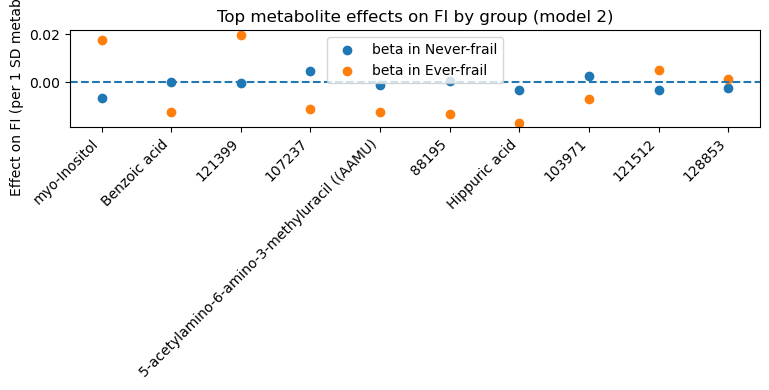

In [230]:
# =========================
# [FIM7] PLOT: TOP metaboliti (per interazione) — effetto stimato in Never vs Ever
# =========================
TOPK = 10
top_int = tab2.sort_values("q_interaction").head(TOPK)

plt.figure(figsize=(8,4))
x = np.arange(len(top_int))
plt.scatter(x, top_int["beta_main_Never"].values, label="beta in Never-frail")
plt.scatter(x, top_int["beta_Ever"].values, label="beta in Ever-frail")
plt.axhline(0, linestyle="--")
plt.xticks(x, top_int["metabolite_original"].astype(str).values, rotation=45, ha="right")
plt.ylabel("Effect on FI (per 1 SD metabolite)")
plt.title("Top metabolite effects on FI by group (model 2)")
plt.legend()
plt.tight_layout()
plt.show()

In [231]:
# =========================
# [FIM8] DIAGNOSTICA SEMPLICE: confronto modello base vs con metaboliti
# (AIC più basso = meglio, in generale)
# =========================
print("AIC model0 (time only):", fit0.aic)
print("AIC model1 (+ metabolites):", fit1.aic)
print("AIC model2 (+ group + interactions):", fit2.aic)

AIC model0 (time only): -6871.793419288297
AIC model1 (+ metabolites): -6919.311053335045
AIC model2 (+ group + interactions): -7506.963074890151
